# Week 8 Linear Algebra

In [39]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
from numpy.linalg import inv, solve

### 1) Solving a System of Linear Equations

The problem gives four equations with four unknown variables. Instead of solving them by hand, I am going to rewrite the system in matrix form so it can be solved using Python.

Once the equations are written as a matrix equation, I can solve for the unknown vector using linear algebra tools. The instructions mention using the inverse of the matrix, but in practice the more stable way in Python is to use np.linalg.solve().

So I am going to:

Solve the system using solve

Verify the answer by multiplying the matrix by my solution and checking that I get the original right hand side back

This way I am not just getting an answer, but confirming that it actually satisfies the system.

In [40]:
# Rewrite the system in matrix form.
# A holds the coefficients and b holds the constants.

A = np.array([
    [27, -10,  4, -29],
    [-16,  5, -2,  18],
    [-17,  4, -2,  20],
    [ -7,  2, -1,   8]
], dtype=float)

b = np.array([1, -1, 0, 1], dtype=float)

A, b

(array([[ 27., -10.,   4., -29.],
        [-16.,   5.,  -2.,  18.],
        [-17.,   4.,  -2.,  20.],
        [ -7.,   2.,  -1.,   8.]]),
 array([ 1., -1.,  0.,  1.]))

In [41]:
# Solve Ax = b directly using a stable method.

x = solve(A, b)

x

array([10.,  3., -9.,  7.])

In [42]:
# Check that the solution actually satisfies the system.

Ax = A @ x

Ax, b, np.allclose(Ax, b)

(array([ 1., -1.,  0.,  1.]), array([ 1., -1.,  0.,  1.]), True)

In [43]:
# Solve again using the inverse to match the hint in the problem.

A_inv = inv(A)
x_via_inverse = A_inv @ b

x_via_inverse, np.allclose(x_via_inverse, x)

(array([10.,  3., -9.,  7.]), True)

### Interpretation

The output vector `x` corresponds to:

- \(x_1 = x[0]\)
- \(x_2 = x[1]\)
- \(x_3 = x[2]\)
- \(x_4 = x[3]\)

The verification step checks that multiplying \(A\) by the computed solution returns \(\mathbf{b}\), confirming the solution is correct.

### 2) Visualizing a Linear Transformation

We are given a 2×2 matrix A with entries involving sqrt_2 divided by 2. This matrix defines the transformation T(v) = A v.

(a) First, I will compute T(x) where x = [2, -2]. This shows what happens to one specific vector when the transformation is applied.

(b) Next, I will visualize how this matrix changes the coordinate grid and the standard basis vectors. This helps show how the transformation affects the entire space, not just one vector.

(c) Using the plot, I will describe what the transformation is doing geometrically.

In [44]:
# Define the transformation matrix using sqrt(2)/2 values.
sqrt2 = np.sqrt(2)

A2 = np.array([
    [sqrt2/2, -sqrt2/2],
    [sqrt2/2,  sqrt2/2]
], dtype=float)

# Apply the transformation to the given vector.
x_vec = np.array([2, -2], dtype=float)

Tx = A2 @ x_vec

Tx

array([2.82842712, 0.        ])

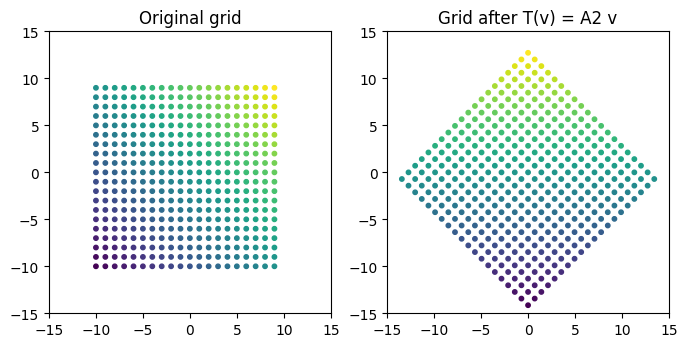

In [45]:
# Mimic Section 7.1.3: make a grid of points, stack them, transform them, then plot before/after.
x = np.arange(-10, 10, 1)
y = np.arange(-10, 10, 1)
xx, yy = np.meshgrid(x, y)

xy = np.vstack([xx.flatten(), yy.flatten()])

trans = A2 @ xy

xx_transformed = trans[0].reshape(xx.shape)
yy_transformed = trans[1].reshape(yy.shape)

f, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].scatter(xx, yy, s=10, c=xx + yy)
axes[0].set_title("Original grid")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(-15, 15)
axes[0].set_ylim(-15, 15)

axes[1].scatter(xx_transformed, yy_transformed, s=10, c=xx + yy)
axes[1].set_title("Grid after T(v) = A2 v")
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlim(-15, 15)
axes[1].set_ylim(-15, 15)

plt.show()

### (c) Geometric description of T

From the matrix structure and the grid plot, this transformation behaves like a rotation.

The columns of the matrix show where the basis vectors end up:
- The first column is \(T(e_1)\)
- The second column is \(T(e_2)\)

Since the columns match a standard rotation matrix with:
\[
\cos(\theta) = \sqrt{2}/2,\ \sin(\theta) = \sqrt{2}/2
\]
this corresponds to a rotation by \(\theta = 45^\circ\) counterclockwise.

So geometrically, T rotates vectors and the entire coordinate grid by about 45 degrees, preserving lengths and angles.

### 3) Finding Eigenvalues and Eigenvectors

The problem gives a 3×3 matrix A.

(a) First, I am going to check whether the vector [1, 2, 3] is an eigenvector. To test this, I will multiply A by that vector and see if the result points in the same direction. If the result is just a constant multiple of the original vector, then it is an eigenvector.

(b) Next, I will do the same thing with the vector [0, 1, 0] and check whether multiplying by A gives a scaled version of that vector.

(c) After checking those two specific cases, I will use Python to compute all eigenvalues and eigenvectors of the matrix so I can see the complete picture.

In [46]:
# Define the matrix from the problem.

A3 = np.array([
    [ 4,  0,  1],
    [-1, -6, -2],
    [ 5,  0,  0]
], dtype=float)

# Helper function to check whether a vector is an eigenvector.
# It computes Av and checks if it is just a scaled version of v.

def is_eigenvector(A, v, tol=1e-9):
    Av = A @ v

    for i in range(len(v)):
        if abs(v[i]) > tol:
            lam = Av[i] / v[i]
            return np.allclose(Av, lam * v, atol=1e-8), lam, Av

    return False, None, Av

In [47]:
# Test whether [1, 2, 3] is an eigenvector.

v1 = np.array([1, 2, 3], dtype=float)
result1, lam1, Av1 = is_eigenvector(A3, v1)

result1, lam1, Av1

(False, np.float64(7.0), array([  7., -19.,   5.]))

In [48]:
# Test whether [0, 1, 0] is an eigenvector.

v2 = np.array([0, 1, 0], dtype=float)
result2, lam2, Av2 = is_eigenvector(A3, v2)

result2, lam2, Av2

(True, np.float64(-6.0), array([ 0., -6.,  0.]))

In [49]:
# Use SymPy to compute the full set of eigenvalues and eigenvectors.

A3_sp = sp.Matrix(A3)
A3_sp.eigenvects()

[(-6.00000000000000,
  1,
  [Matrix([
   [   0],
   [-1.0],
   [   0]])]),
 (5.00000000000000,
  1,
  [Matrix([
   [-0.707106781186548],
   [ 0.192847303959968],
   [-0.707106781186548]])]),
 (-1.00000000000000,
  1,
  [Matrix([
   [-0.235702260395516],
   [-0.424264068711929],
   [  1.17851130197758]])])]

### Eigen summary

- Parts (a) and (b) are verified by checking whether \(A v\) is a scalar multiple of \(v\).
- Part (c) is handled using SymPy so we get exact eigenvalues and eigenvectors (when possible).

In my write-up, I will state:
1) Whether each candidate vector is an eigenvector
2) If yes, what the eigenvalue is
3) Then list all eigenvalues and one eigenvector basis for each eigenvalue from Python output

## 4) Principal Component Analysis (PCA)

We use `video game data.csv` with columns:
- name of the game
- critic score
- user score
- total sales

(a) Make a scatterplot of user scores vs critic scores

(b) Sketch approximate directions of the first and second principal components
-  We can do this in Python by:
1) Taking only the (critic score, user score) columns
2) Centering the data
3) Computing PCA directions
4) Drawing arrows showing PC1 and PC2 directions on the scatterplot

In [50]:
# Update the filename if needed to match exactly what you have locally
df = pd.read_csv("video_game_data.csv")

df.head()

,Rank,Name,Genre,ESRB_Rating,Platform,Publisher,Developer,Critic_Score,User_Score,Total_Shipped,Global_Sales,NA_Sales,PAL_Sales,JP_Sales,Other_Sales,Year
0,1,Wii Sports,Sports,E,Wii,Nintendo,Nintendo EAD,7.7,NaN,82.86,NaN,NaN,NaN,NaN,NaN,2006.0
1,2,Super Mario Bros.,Platform,NaN,NES,Nintendo,Nintendo EAD,10.0,NaN,40.24,NaN,NaN,NaN,NaN,NaN,1985.0
2,3,Mario Kart Wii,Racing,E,Wii,Nintendo,Nintendo EAD,8.2,9.1,37.14,NaN,NaN,NaN,NaN,NaN,2008.0
3,4,PlayerUnknown's Battlegrounds,Shooter,NaN,PC,PUBG Corporation,PUBG Corporation,NaN,NaN,36.60,NaN,NaN,NaN,NaN,NaN,2017.0
4,5,Wii Sports Resort,Sports,E,Wii,Nintendo,Nintendo EAD,8.0,8.8,33.09,NaN,NaN,NaN,NaN,NaN,2009.0


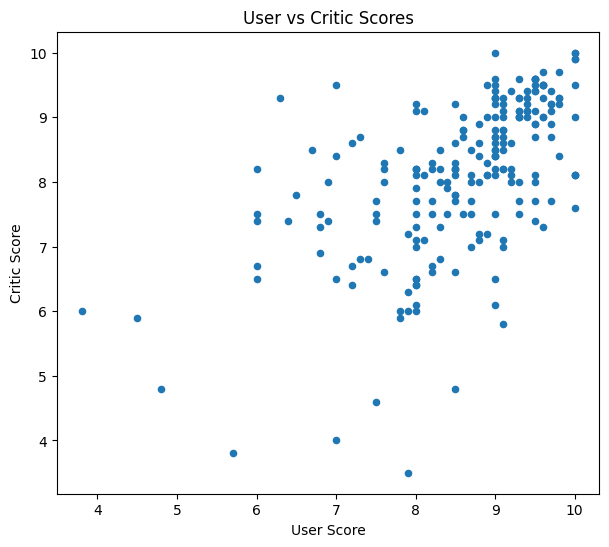

In [51]:
# Remove extra spaces from column names to avoid indexing issues.
df.columns = df.columns.str.strip()

# Select the two variables I want to analyze.
critic_col = "Critic_Score"
user_col = "User_Score"

# Extract the two-dimensional data and remove missing values.
data_2d = df[[critic_col, user_col]].dropna()

# Convert to a numeric matrix.
X = data_2d[[user_col, critic_col]].to_numpy(dtype=float)

# Plot the original data points.
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], s=20)

plt.xlabel("User Score")
plt.ylabel("Critic Score")
plt.title("User vs Critic Scores")

plt.gca().set_aspect("auto")
plt.show()

## PCA on Critic vs User Scores

Now that I can see the relationship between user and critic scores, I will use PCA to find the main directions of variation in the data.

Steps:
1. Use only the two columns (user score and critic score)
2. Center the data
3. Fit PCA with 2 components
4. Plot the same scatterplot and draw PC1 and PC2 directions
5. Briefly describe what PC1 and PC2 mean based on the direction of the arrows

In [52]:
# Use the same columns we already detected
X = data_2d[[user_col, critic_col]].to_numpy(dtype=float)

# Center the data (subtract the mean of each column)
X_centered = X - X.mean(axis=0)

X.shape, X_centered.shape

((218, 2), (218, 2))

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_centered)

components = pca.components_              # direction vectors for PC1 and PC2
explained = pca.explained_variance_ratio_ # percent of variance explained

print("PCA directions (rows are PC1 then PC2):")
print(components)

print("\nExplained variance ratio (PC1, PC2):")
print(explained)

PCA directions (rows are PC1 then PC2):
[[ 0.63321609  0.77397505]
 [ 0.77397505 -0.63321609]]

Explained variance ratio (PC1, PC2):
[0.79518618 0.20481382]


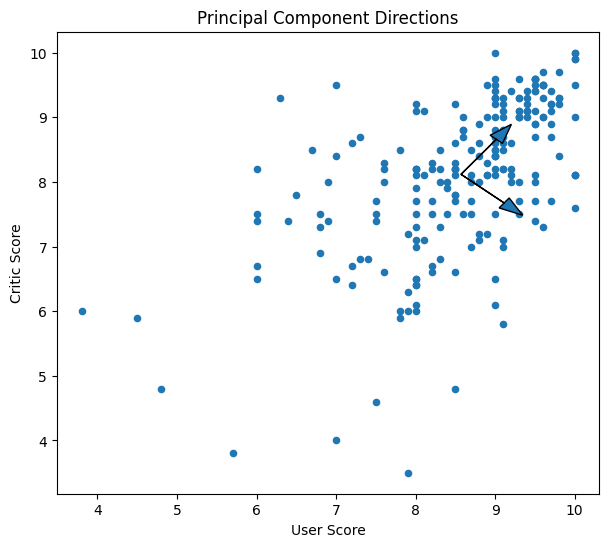

In [54]:
# Compute the mean vector of the data.
mean_vector = X.mean(axis=0)

# Extract the principal component directions.
pc1 = components[0]
pc2 = components[1]

# Plot the original data.
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], s=20)

plt.xlabel("User Score")
plt.ylabel("Critic Score")
plt.title("Principal Component Directions")

# Draw PC1 as a direction vector from the mean.
plt.arrow(
    mean_vector[0], mean_vector[1],
    pc1[0], pc1[1],
    head_width=0.2,
    length_includes_head=True
)

# Draw PC2 as a direction vector from the mean.
plt.arrow(
    mean_vector[0], mean_vector[1],
    pc2[0], pc2[1],
    head_width=0.2,
    length_includes_head=True
)

plt.gca().set_aspect("auto")
plt.show()

### PCA interpretation

PC1 is the direction where the data spreads out the most.  
PC2 is the second main direction of spread and it is perpendicular to PC1.

If PC1 points up and to the right, it suggests user scores and critic scores tend to increase together.  
If PC1 is more horizontal or vertical, it suggests one score varies more than the other.

## PCA using Critic Score, User Score, and Total Sales

Next I will include total sales as a third feature and run PCA again.
This helps show whether the main variation is mostly driven by review scores, sales, or both.

In [55]:
# Find the exact sales column name and run 3D PCA

# Get the real sales column from the dataframe
sales_col = [c for c in df.columns if "sales" in c.lower()][0]

# Build dataset
data_3d = df[[user_col, critic_col, sales_col]].dropna()

# Convert to matrix
X3 = data_3d[[user_col, critic_col, sales_col]].to_numpy(dtype=float)

# Center the data
X3_centered = X3 - X3.mean(axis=0)

# PCA in 3 dimensions
pca3 = PCA(n_components=3)
pca3.fit(X3_centered)

pca3.explained_variance_ratio_, pca3.components_

(array([0.76313404, 0.17317294, 0.06369302]),
 array([[ 0.12352866,  0.29957981,  0.94604049],
        [ 0.6808852 ,  0.66793927, -0.3004205 ],
        [ 0.72189751, -0.68125551,  0.12146982]]))

### PCA interpretation with total sales

PC1 explains about 76% of the total variation, which means most of the structure in the data lies along one main direction.

The weights for PC1 are: [0.1235, 0.2996, 0.9460]

Since the largest weight is on total sales (about 0.95), this tells me that once sales is included, the main variation in the dataset is mostly driven by sales rather than review scores.

PC2 explains about 17% of the variation and has large weights on user and critic scores. This suggests the second main direction captures variation in review scores after accounting for sales.